In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [4]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8166666666666667


In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[38  3]
 [ 8 11]]


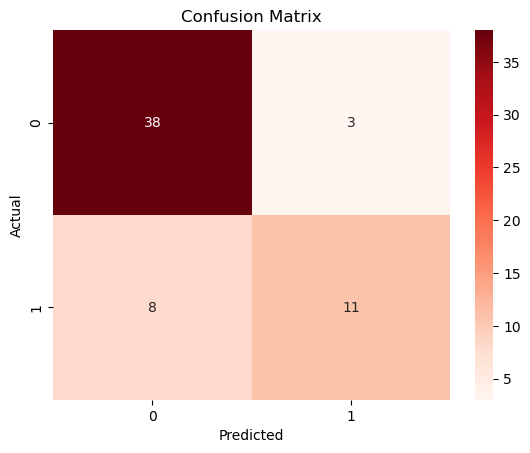

In [13]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.93      0.87        41
           1       0.79      0.58      0.67        19

    accuracy                           0.82        60
   macro avg       0.81      0.75      0.77        60
weighted avg       0.81      0.82      0.81        60



In [15]:
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

ROC AUC Score: 0.858793324775353


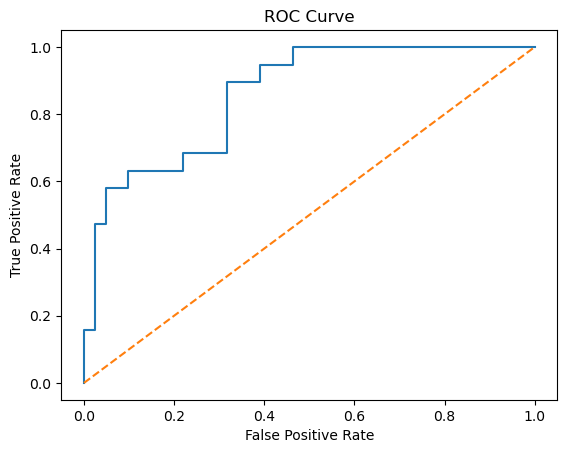

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [17]:
age = float(input("Age: "))
anaemia = int(input("Anaemia (1/0): "))
cpk = float(input("Creatinine Phosphokinase: "))
diabetes = int(input("Diabetes (1/0): "))
ef = float(input("Ejection Fraction: "))
hbp = int(input("High Blood Pressure (1/0): "))
platelets = float(input("Platelets: "))
scr = float(input("Serum Creatinine: "))
ss = float(input("Serum Sodium: "))
sex = int(input("Sex (1 Male / 0 Female): "))
smoking = int(input("Smoking (1/0): "))
time = int(input("Follow-up Time: "))

sample = pd.DataFrame([{
    "age": age,
    "anaemia": anaemia,
    "creatinine_phosphokinase": cpk,
    "diabetes": diabetes,
    "ejection_fraction": ef,
    "high_blood_pressure": hbp,
    "platelets": platelets,
    "serum_creatinine": scr,
    "serum_sodium": ss,
    "sex": sex,
    "smoking": smoking,
    "time": time
}])

sample_scaled = scaler.transform(sample)

result = model.predict(sample_scaled)

if result[0] == 1:
    print("Prediction: Death Event Risk")
else:
    print("Prediction: Survived")

Age:  50
Anaemia (1/0):  1
Creatinine Phosphokinase:  1
Diabetes (1/0):  1
Ejection Fraction:  1
High Blood Pressure (1/0):  1
Platelets:  1
Serum Creatinine:  1
Serum Sodium:  1
Sex (1 Male / 0 Female):  1
Smoking (1/0):  1
Follow-up Time:  1


Prediction: Death Event Risk
